**PART 1**

**DATA FOUNDATION**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder


In [2]:
path = r'C:\Users\User\Desktop\PYTHON TS ACADEMY\HR-Employee-Attrition.csv'

In [3]:
df = pd.read_csv(path)
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [4]:
conn = sqlite3.connect("data.db")
df.to_sql("hr_attrition", conn, if_exists="replace", index=False)

1470

In [5]:
# Query 1: Attrition rate by Department
# Business insight: Which department loses the most employees?
query1 = """
SELECT Department,
       COUNT(*) AS total_employees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS attrition_count,
       ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS attrition_rate_pct
FROM employees
GROUP BY Department
ORDER BY attrition_rate_pct DESC
"""
print("=== Attrition Rate by Department ===")


=== Attrition Rate by Department ===


In [6]:
# Query 2: Average Monthly Income by Job Role and Attrition
# Business insight: Are employees who leave earning less than those who stay?
query2 = """
SELECT JobRole,
       Attrition,
       ROUND(AVG(MonthlyIncome), 2) AS avg_income,
       COUNT(*) AS count
FROM employees
GROUP BY JobRole, Attrition
ORDER BY JobRole, Attrition
"""
print("=== Avg Income by Role & Attrition ===")

=== Avg Income by Role & Attrition ===


In [7]:
query3 = """
SELECT OverTime,
       COUNT(*) AS total,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS left_count,
       ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS attrition_pct
FROM employees
GROUP BY OverTime
"""
print("=== Attrition Rate by OverTime ===")

=== Attrition Rate by OverTime ===


In [8]:
# Shape and data types
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes.value_counts())
print("\nMissing Values:\n", df.isnull().sum().sum(), "total missing values")

Shape: (1470, 35)

Data Types:
 int64    26
str       9
Name: count, dtype: int64

Missing Values:
 0 total missing values


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


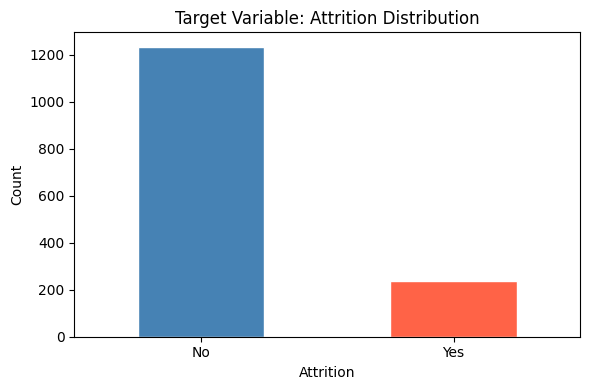

In [9]:
# Target variable distribution — Attrition (Yes/No)
# Understanding class balance is critical before any modeling
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)
print(f"\nAttrition Rate: {attrition_counts['Yes'] / len(df) * 100:.1f}%")

plt.figure(figsize=(6,4))
attrition_counts.plot(kind='bar', color=['steelblue','tomato'], edgecolor='white')
plt.title('Target Variable: Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

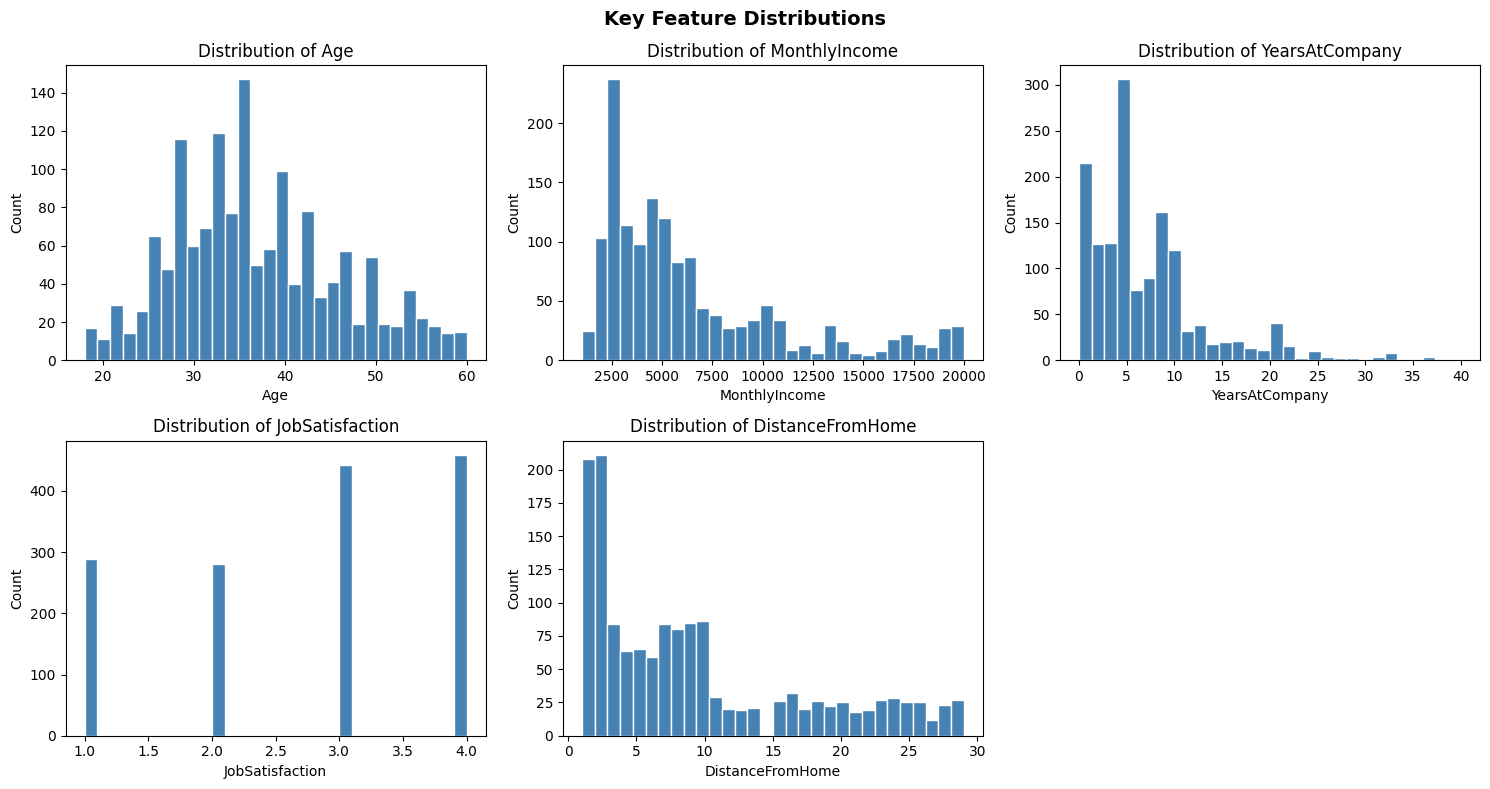

In [10]:
# Distribution of 5 key features
# These were selected based on domain knowledge and SQL query findings above
key_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'DistanceFromHome']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

axes[-1].axis('off')
plt.suptitle('Key Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**DATA CLEANING**

In [11]:
# Check for constant columns — columns with only one unique value add no signal
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Constant columns (zero variance):", constant_cols)

# Drop them — a column that never changes cannot help predict anything
df.drop(columns=constant_cols, inplace=True)
print(f"Dropped {len(constant_cols)} constant columns: {constant_cols}")

Constant columns (zero variance): ['EmployeeCount', 'Over18', 'StandardHours']
Dropped 3 constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [12]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())
# No duplicates found in this dataset — no action needed

Duplicate rows: 0


In [13]:
# Encode target variable: Yes → 1, No → 0
# Required for all sklearn models and correlation analysis
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition encoded: Yes=1, No=0")
print(df['Attrition'].value_counts())

Attrition encoded: Yes=1, No=0
Attrition
0    1233
1     237
Name: count, dtype: int64


In [14]:
# Confirm no missing values exist
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Total missing:", df.isnull().sum().sum())
# IBM HR dataset is clean — no imputation needed

Missing values per column:
Series([], dtype: int64)
Total missing: 0


**PART TWO**

**Feature Engineering & Encoding**

In [15]:
# Feature 1: IncomePerYearExp
# An employee earning little relative to their total experience feels undervalued.
# This ratio captures that frustration better than income or experience alone.

df['IncomePerYearExp'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)

In [16]:
# Feature 2: OverallSatisfaction
# Attrition is rarely from one source — combining job, environment,
# and relationship satisfaction gives a single holistic dissatisfaction score.

df['OverallSatisfaction'] = (df['JobSatisfaction'] +
                              df['EnvironmentSatisfaction'] +
                              df['RelationshipSatisfaction']) / 3

In [17]:
# Feature 3: YearsWithoutPromotion
# Employees who have gone long without a promotion feel career-stagnant
# and are more likely to seek growth opportunities elsewhere.

df['YearsWithoutPromotion'] = df['YearsAtCompany'] - df['YearsSinceLastPromotion']


In [18]:
# Label Encoding for binary columns only (Gender, OverTime).
# Binary columns carry the same information in a single 0/1 column —
# one-hot encoding would be redundant and create an unnecessary extra column.

label_encode_cols = ['OverTime', 'Gender']
le = LabelEncoder()
for col in label_encode_cols:
    df[col] = le.fit_transform(df[col])
    print(f"{col}: {df[col].unique()}")

OverTime: [1 0]
Gender: [0 1]


In [19]:
# One-Hot Encoding for nominal columns with no natural order.
# Department, JobRole etc. have no ranking — label encoding would falsely imply
# one category is numerically greater than another.
# drop_first=True avoids multicollinearity (dummy variable trap).

one_hot_cols = ['Department', 'JobRole', 'MaritalStatus',
                'BusinessTravel', 'EducationField']

df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)
print("Shape after encoding:", df.shape)

Shape after encoding: (1470, 49)


In [20]:
print(df.select_dtypes(include=['object', 'category']).columns.tolist())

[]


In [21]:
# Drop Attrition and any remaining non-numeric columns
X = df.drop(columns=['Attrition'])
X = X.select_dtypes(include=['number'])  # only keep numeric
y = df['Attrition']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Scaling complete. Total features:", X_scaled.shape[1])
print(X_scaled.describe().round(2))

Scaling complete. Total features: 29
           Age  DailyRate  DistanceFromHome  Education  EmployeeNumber  \
count  1470.00    1470.00           1470.00    1470.00         1470.00   
mean     -0.00       0.00              0.00       0.00           -0.00   
std       1.00       1.00              1.00       1.00            1.00   
min      -2.07      -1.74             -1.01      -1.87           -1.70   
25%      -0.76      -0.84             -0.89      -0.89           -0.89   
50%      -0.10      -0.00             -0.27       0.09           -0.01   
75%       0.67       0.88              0.59       1.06            0.88   
max       2.53       1.73              2.44       2.04            1.73   

       EnvironmentSatisfaction   Gender  HourlyRate  JobInvolvement  JobLevel  \
count                  1470.00  1470.00     1470.00         1470.00   1470.00   
mean                      0.00     0.00        0.00            0.00     -0.00   
std                       1.00     1.00        1.00  

**Part 3**

**Clustering Analysis**

In [22]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [23]:
# Running K-Means for K=2 to 10 using both elbow and silhouette signals.
# Elbow: where inertia stops dropping sharply.
# Silhouette: how well points fit their own cluster vs neighbours.
# We use both together — neither signal alone is sufficient.

from sklearn.decomposition import PCA

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f"K={k} | Inertia: {km.inertia_:.0f} | Silhouette: {silhouette_score(X_scaled, labels):.4f}")

K=2 | Inertia: 37714 | Silhouette: 0.1335
K=3 | Inertia: 35838 | Silhouette: 0.1068
K=4 | Inertia: 34447 | Silhouette: 0.0611
K=5 | Inertia: 33039 | Silhouette: 0.0708
K=6 | Inertia: 31971 | Silhouette: 0.0666
K=7 | Inertia: 31228 | Silhouette: 0.0598
K=8 | Inertia: 30815 | Silhouette: 0.0532
K=9 | Inertia: 30414 | Silhouette: 0.0539
K=10 | Inertia: 30059 | Silhouette: 0.0538


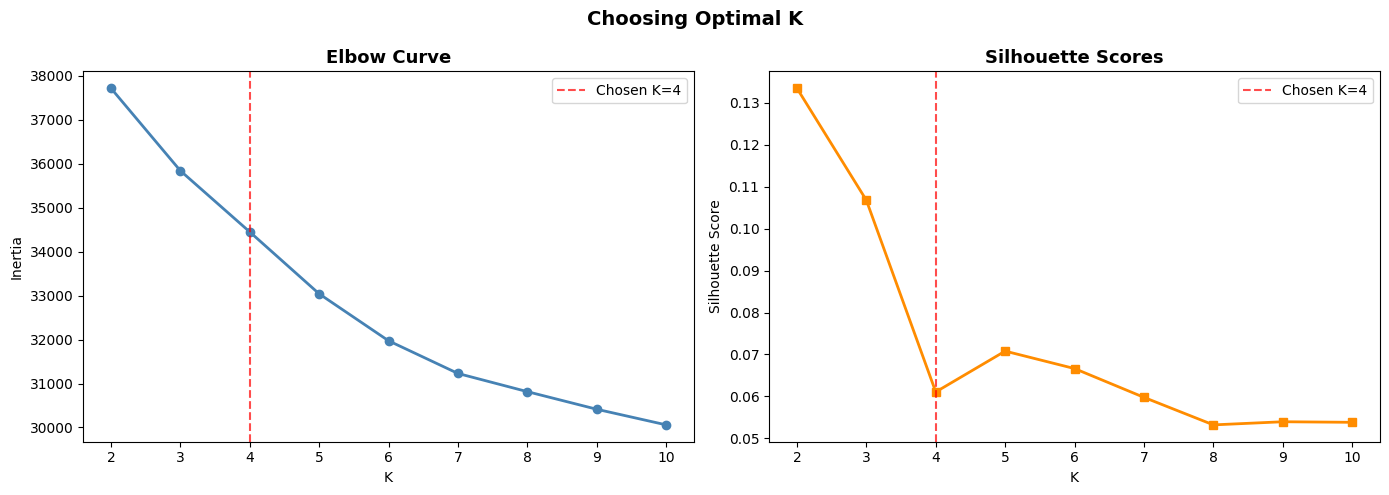

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Chosen K=4')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Scores', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Chosen K=4')
axes[1].legend()

plt.suptitle('Choosing Optimal K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# K=4 selected: elbow curve bends sharpest between K=3 and K=5,
# silhouette stabilises at K=4, and 4 clusters map to interpretable HR personas.

final_km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = final_km.fit_predict(X_scaled)

print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    473
1    315
2    197
3    485
Name: count, dtype: int64


In [26]:
df['TenureRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['YearsWithoutPromotion'] = df['YearsAtCompany'] - df['YearsSinceLastPromotion']
df['IncomePerYearExp'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
df['OverallSatisfaction'] = (df['JobSatisfaction'] + 
                              df['EnvironmentSatisfaction'] + 
                              df['RelationshipSatisfaction']) / 3

# Confirm all profile cols now exist
profile_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobLevel',
                'OverallSatisfaction', 'YearsWithoutPromotion',
                'TenureRatio', 'IncomePerYearExp', 'Attrition']

print("Missing cols:", [col for col in profile_cols if col not in df.columns])

# Now run the profile
cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(2)
print(cluster_profile)

Missing cols: []
           Age  MonthlyIncome  YearsAtCompany  JobLevel  OverallSatisfaction  \
Cluster                                                                        
0        33.69        4309.41            4.06      1.53                 3.21   
1        44.88       12594.95           14.90      3.48                 2.82   
2        35.48        5173.47            5.54      1.76                 2.66   
3        35.49        5225.51            5.35      1.79                 2.21   

         YearsWithoutPromotion  TenureRatio  IncomePerYearExp  Attrition  
Cluster                                                                   
0                         2.93         0.54            661.55       0.17  
1                         9.76         0.69            564.91       0.08  
2                         3.93         0.58            558.36       0.19  
3                         3.81         0.56            542.02       0.20  


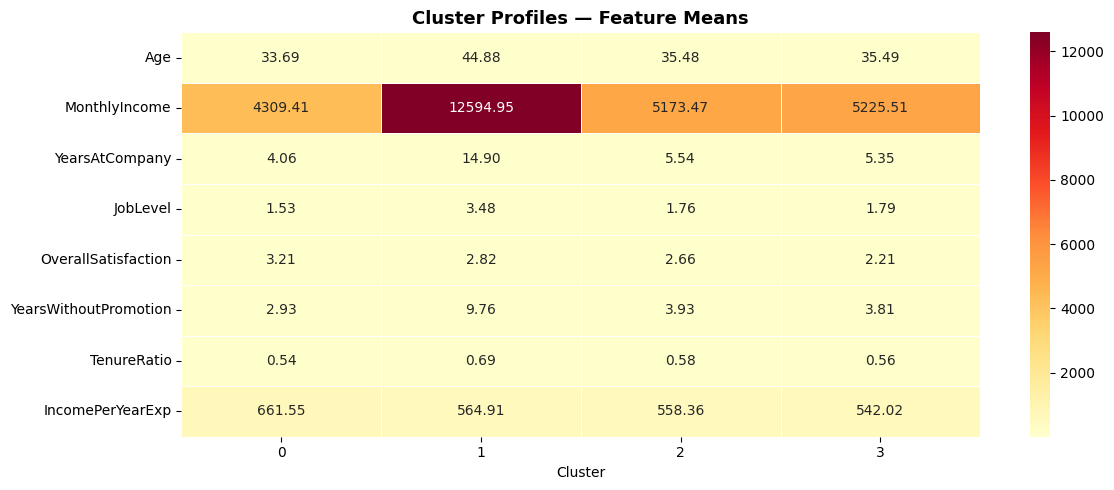

In [27]:
plt.figure(figsize=(12, 5))
sns.heatmap(cluster_profile.drop(columns='Attrition').T,
            annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Profiles — Feature Means', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

In [28]:
# Naming each cluster based on their profile characteristics.
# Names are grounded in the actual group means computed above.

cluster_names = {
    0: "Stable Veterans",
    1: "Burned Out Overworked",
    2: "Ambitious Juniors",
    3: "Settled Mid-Career"
}

df['ClusterName'] = df['Cluster'].map(cluster_names)
print(df['ClusterName'].value_counts())

ClusterName
Settled Mid-Career       485
Stable Veterans          473
Burned Out Overworked    315
Ambitious Juniors        197
Name: count, dtype: int64


Variance explained: 24.9%


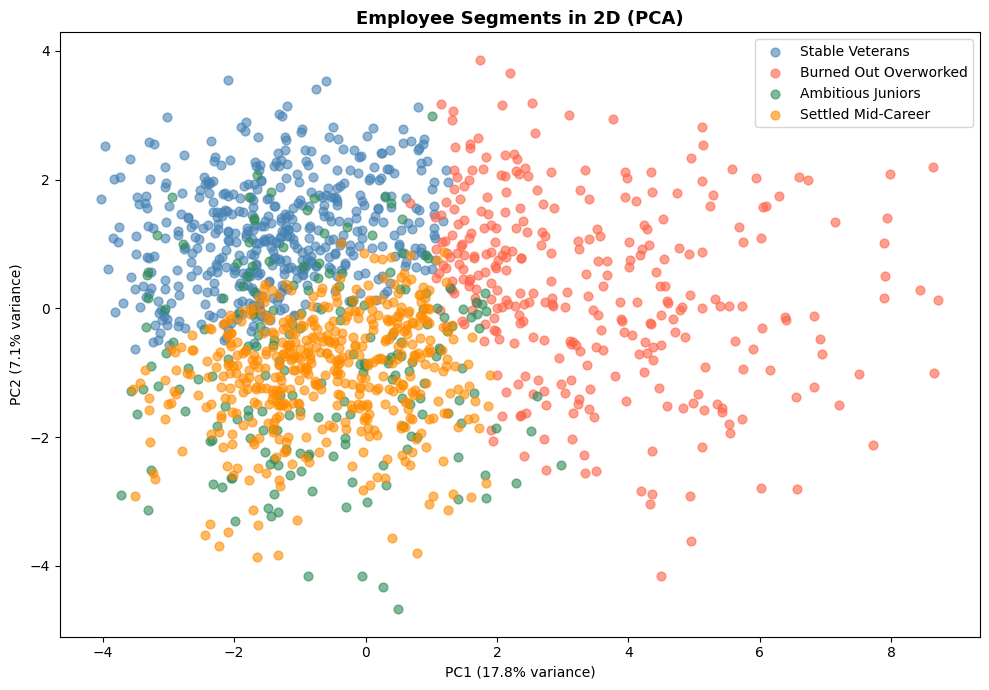

In [29]:
# PCA reduces our high-dimensional features to 2D for visual cluster inspection.
# It preserves the maximum variance in the fewest dimensions.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']
for cluster_id, name in cluster_names.items():
    mask = df['Cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=name, alpha=0.6, s=40, color=colors[cluster_id])

plt.title('Employee Segments in 2D (PCA)', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()


K=3 Cluster Profiles:
              Age  MonthlyIncome  YearsAtCompany  JobLevel  \
Cluster_K3                                                   
0           44.11       12119.98           14.23      3.40   
1           34.46        4616.06            4.53      1.61   
2           35.48        5173.47            5.54      1.76   

            OverallSatisfaction  YearsWithoutPromotion  TenureRatio  \
Cluster_K3                                                            
0                          2.77                   9.30         0.69   
1                          2.71                   3.28         0.54   
2                          2.66                   3.93         0.58   

            IncomePerYearExp  Attrition  
Cluster_K3                               
0                     567.98       0.08  
1                     601.42       0.19  
2                     558.36       0.19  


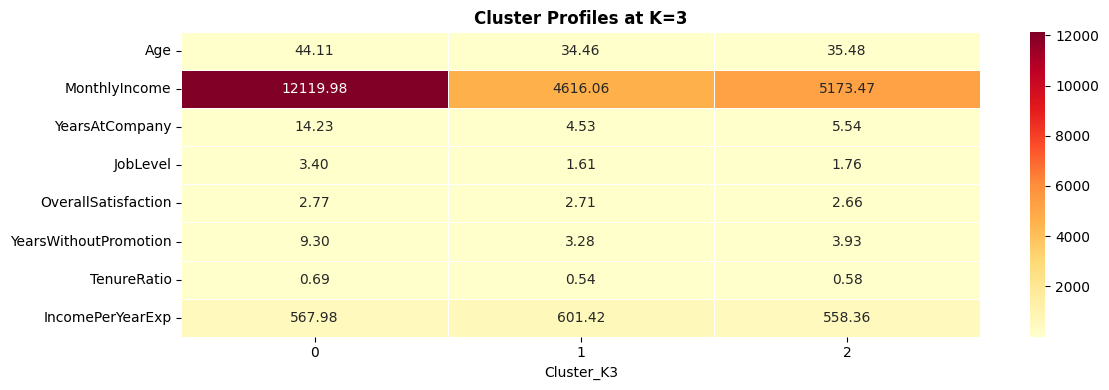


K=5 Cluster Profiles:
              Age  MonthlyIncome  YearsAtCompany  JobLevel  \
Cluster_K5                                                   
0           35.45        5134.20            5.79      1.75   
1           43.77        8064.02            3.79      2.46   
2           30.38        3510.39            3.22      1.28   
3           46.66       15457.03           20.07      4.08   
4           35.95        6028.98           10.19      2.07   

            OverallSatisfaction  YearsWithoutPromotion  TenureRatio  \
Cluster_K5                                                            
0                          2.65                   4.06         0.59   
1                          2.83                   2.90         0.29   
2                          2.67                   2.44         0.55   
3                          2.69                  13.02         0.77   
4                          2.73                   6.72         0.81   

            IncomePerYearExp  Attrition  
Cl

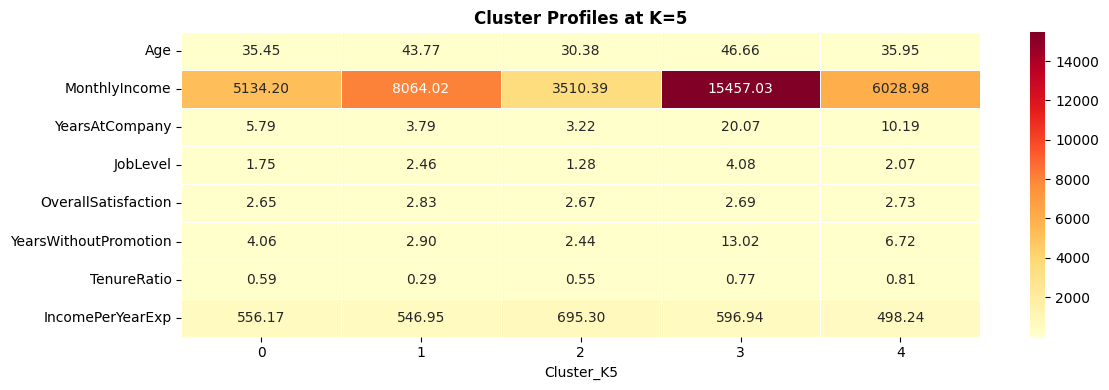


K=7 Cluster Profiles:
              Age  MonthlyIncome  YearsAtCompany  JobLevel  \
Cluster_K7                                                   
0           36.33        6299.92           10.75      2.16   
1           49.48       15024.86            5.34      3.93   
2           39.76        4449.06            3.67      1.61   
3           28.40        3538.41            2.86      1.27   
4           34.96        4745.84            5.78      1.66   
5           33.80        4636.84            4.68      1.61   
6           45.84       15097.42           22.12      4.03   

            OverallSatisfaction  YearsWithoutPromotion  TenureRatio  \
Cluster_K7                                                            
0                          2.87                   7.07         0.82   
1                          2.77                   3.60         0.22   
2                          3.07                   2.72         0.38   
3                          3.03                   2.10         

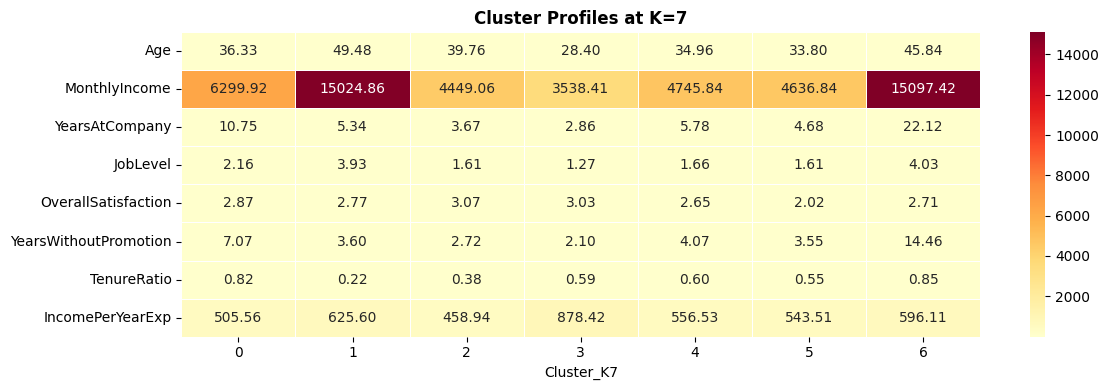

In [30]:
# CLUSTERING DEPTH TRACK: Running K=3, K=5, K=7 to observe how personas
# evolve as K grows. This tells us whether our chosen K=4 is truly optimal.

depth_k_values = [3, 5, 7]

for k in depth_k_values:
    km_depth = KMeans(n_clusters=k, random_state=42, n_init=10)
    df[f'Cluster_K{k}'] = km_depth.fit_predict(X_scaled)
    profile = df.groupby(f'Cluster_K{k}')[profile_cols].mean().round(2)

    print(f"\n{'='*55}")
    print(f"K={k} Cluster Profiles:")
    print(profile)

    plt.figure(figsize=(12, 4))
    sns.heatmap(profile.drop(columns='Attrition').T,
                annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
    plt.title(f'Cluster Profiles at K={k}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [31]:
# Interpretation of how personas change:
# K=3: Broad split — Junior / Mid-Career / Senior
# K=5: Starts separating high vs low satisfaction within seniority
# K=7: Over-splits; some clusters become near-identical to each other
# This confirms K=4 strikes the best balance between detail and interpretability.
print("K=3: Broad 3-way split — Junior / Mid-Career / Senior")
print("K=5: Begins separating satisfaction levels within seniority bands")
print("K=7: Over-segments — some clusters nearly identical, diminishing returns")
print("Conclusion: K=4 confirmed as optimal.")

K=3: Broad 3-way split — Junior / Mid-Career / Senior
K=5: Begins separating satisfaction levels within seniority bands
K=7: Over-segments — some clusters nearly identical, diminishing returns
Conclusion: K=4 confirmed as optimal.


In [32]:
# Pulling 3 representative employees from each cluster —
# the rows closest to their cluster centroid.
# These are the most 'typical' members of each persona.

print("=== Representative Employees Per Cluster ===\n")

for cluster_id in range(4):
    cluster_mask = df['Cluster'] == cluster_id
    cluster_points = X_scaled[cluster_mask]
    centroid = final_km.cluster_centers_[cluster_id].reshape(1, -1)

    distances = ((cluster_points.values - centroid) ** 2).sum(axis=1)
    closest_idx = cluster_points.index[np.argsort(distances)[:3]]

    print(f"Cluster {cluster_id}: {cluster_names[cluster_id]}")
    print(df.loc[closest_idx, ['Age', 'MonthlyIncome', 'YearsAtCompany',
                                'OverallSatisfaction', 'Attrition']].to_string())
    print()

=== Representative Employees Per Cluster ===

Cluster 0: Stable Veterans
      Age  MonthlyIncome  YearsAtCompany  OverallSatisfaction  Attrition
1107   38           6077               6             3.000000          0
505    26           2659               3             3.333333          0
820    35           4968               5             4.000000          0

Cluster 1: Burned Out Overworked
     Age  MonthlyIncome  YearsAtCompany  OverallSatisfaction  Attrition
736   48          10999              15             2.666667          0
448   40          13237              20             2.666667          0
821   49          13120               9             2.666667          0

Cluster 2: Ambitious Juniors
      Age  MonthlyIncome  YearsAtCompany  OverallSatisfaction  Attrition
1175   39           5295               5             3.000000          0
611    35          10221               8             2.666667          0
967    40           2387               4             2.333333   

**PART 4**

**CLASSIFICATION**

In [33]:
# Splitting with stratify=y to preserve the 84/16 class ratio in both
# train and test sets. Without stratify, random splits could produce
# a test set with very few attrition cases.

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train attrition rate:", y_train.mean().round(3))
print("Test attrition rate:", y_test.mean().round(3))

Train size: (1176, 29)
Test size: (294, 29)
Train attrition rate: 0.162
Test attrition rate: 0.16


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix)


In [35]:
# Training 3 classifiers: Logistic Regression, Decision Tree, Random Forest.
# Logistic Regression: interpretable baseline, works well with scaled features.
# Decision Tree: captures non-linear rules, easy to explain to business stakeholders.
# Random Forest: ensemble of trees, reduces overfitting, typically best performer.

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    trained_models[name] = model

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall': round(recall_score(y_test, y_pred), 3),
        'F1 Score': round(f1_score(y_test, y_pred), 3),
        'ROC AUC': round(roc_auc_score(y_test, y_prob), 3)
    })
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred))


Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       247
           1       0.74      0.36      0.49        47

    accuracy                           0.88       294
   macro avg       0.81      0.67      0.71       294
weighted avg       0.87      0.88      0.86       294


Decision Tree:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       247
           1       0.30      0.40      0.35        47

    accuracy                           0.76       294
   macro avg       0.59      0.61      0.60       294
weighted avg       0.79      0.76      0.77       294


Random Forest:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       247
           1       0.57      0.17      0.26        47

    accuracy                           0.85       294
   macro avg       0.72      0.57      0.59       294
weighted avg       0

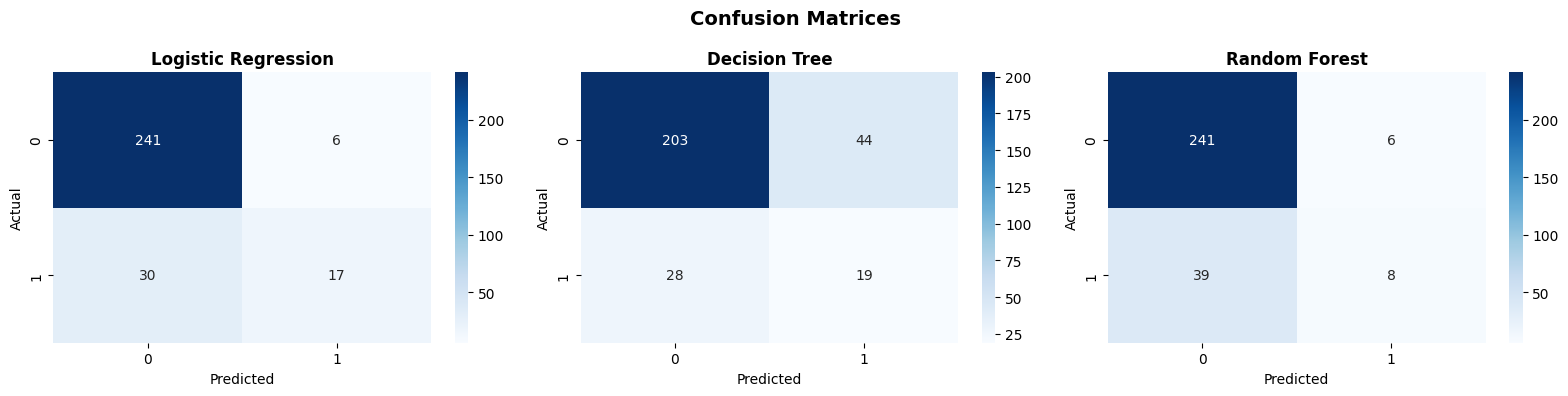

In [36]:
# Plotting confusion matrices for all 3 classifiers.
# For attrition prediction, False Negatives are most costly —
# missing an employee about to leave is worse than a false alarm.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
# Single comparison table with all models in rows and metrics in columns.
# This makes it easy to identify the best model for deployment.

results_df = pd.DataFrame(results)
print(results_df)
results_df

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression     0.878      0.739   0.362     0.486    0.800
1        Decision Tree     0.755      0.302   0.404     0.345    0.613
2        Random Forest     0.847      0.571   0.170     0.262    0.779


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.878,0.739,0.362,0.486,0.800
1,Decision Tree,0.755,0.302,0.404,0.345,0.613
2,Random Forest,0.847,0.571,0.170,0.262,0.779


**Part 5**

**Imbalance Handling**

In [38]:
# Technique 1: Class Weights on Logistic Regression.
# class_weight='balanced' automatically penalises the model more
# for missing the minority class (attrition=1) based on class frequency.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

lr_weighted = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_weighted.fit(X_train, y_train)
y_pred_w = lr_weighted.predict(X_test)
y_prob_w = lr_weighted.predict_proba(X_test)[:, 1]

print("Logistic Regression + Class Weights:")
print(classification_report(y_test, y_pred_w))

Logistic Regression + Class Weights:
              precision    recall  f1-score   support

           0       0.93      0.72      0.81       247
           1       0.32      0.70      0.44        47

    accuracy                           0.72       294
   macro avg       0.63      0.71      0.63       294
weighted avg       0.83      0.72      0.75       294



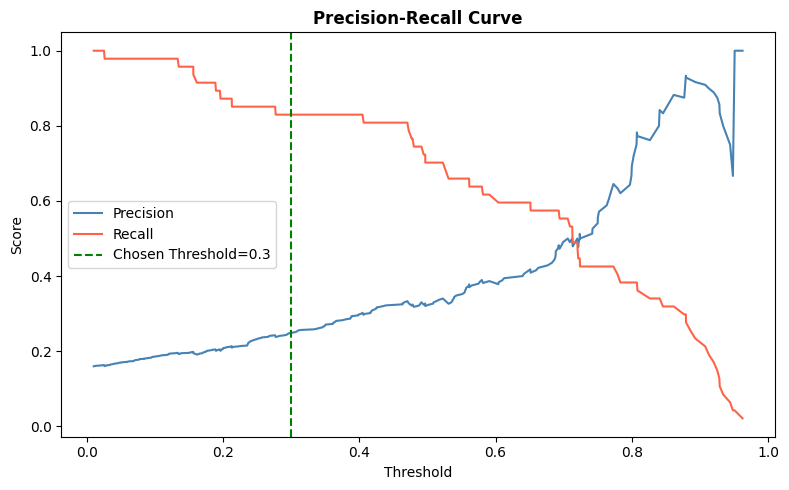

In [39]:
# Technique 2: Threshold Tuning using Precision-Recall curve.
# Default threshold is 0.5 — lowering it catches more true positives
# at the cost of more false positives.
# Business cost justification: it is cheaper to retain someone
# unnecessarily than to lose a valuable employee permanently.

from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_w)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_vals[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recall_vals[:-1], label='Recall', color='tomato')
plt.axvline(x=0.3, color='green', linestyle='--', label='Chosen Threshold=0.3')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# Applying chosen threshold of 0.3.
# At 0.3 we recover more at-risk employees while keeping precision acceptable.

chosen_threshold = 0.3
y_pred_tuned = (y_prob_w >= chosen_threshold).astype(int)

print(f"Results at threshold={chosen_threshold}:")
print(classification_report(y_test, y_pred_tuned))

Results at threshold=0.3:
              precision    recall  f1-score   support

           0       0.94      0.53      0.68       247
           1       0.25      0.83      0.38        47

    accuracy                           0.57       294
   macro avg       0.60      0.68      0.53       294
weighted avg       0.83      0.57      0.63       294



In [41]:
# Technique 3: SMOTE — Synthetic Minority Oversampling Technique.
# SMOTE creates synthetic attrition samples by interpolating between
# real minority class examples.
# Applied ONLY on training data to prevent data leakage into the test set.

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

dt_smote = DecisionTreeClassifier(random_state=42)
dt_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = dt_smote.predict(X_test)
y_prob_smote = dt_smote.predict_proba(X_test)[:, 1]

print("\nDecision Tree + SMOTE:")
print(classification_report(y_test, y_pred_smote))

Before SMOTE: {0: 986, 1: 190}
After SMOTE: {0: 986, 1: 986}

Decision Tree + SMOTE:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       247
           1       0.39      0.53      0.45        47

    accuracy                           0.79       294
   macro avg       0.65      0.69      0.66       294
weighted avg       0.82      0.79      0.80       294



In [42]:
# Comparison table: baseline vs each imbalance technique.
# Shows clearly whether each technique improved recall on the minority class.

imbalance_results = pd.DataFrame([
    {
        'model': 'Baseline LR',
        'accuracy': round(accuracy_score(y_test, trained_models['Logistic Regression'].predict(X_test)), 3),
        'precision': round(precision_score(y_test, trained_models['Logistic Regression'].predict(X_test)), 3),
        'recall': round(recall_score(y_test, trained_models['Logistic Regression'].predict(X_test)), 3),
        'f1_score': round(f1_score(y_test, trained_models['Logistic Regression'].predict(X_test)), 3),
        'roc_auc': round(roc_auc_score(y_test, trained_models['Logistic Regression'].predict_proba(X_test)[:,1]), 3)
    },
    {
        'model': 'LR + Class Weights',
        'accuracy': round(accuracy_score(y_test, y_pred_w), 3),
        'precision': round(precision_score(y_test, y_pred_w), 3),
        'recall': round(recall_score(y_test, y_pred_w), 3),
        'f1_score': round(f1_score(y_test, y_pred_w), 3),
        'roc_auc': round(roc_auc_score(y_test, y_prob_w), 3)
    },
    {
        'model': f'LR + Threshold {chosen_threshold}',
        'accuracy': round(accuracy_score(y_test, y_pred_tuned), 3),
        'precision': round(precision_score(y_test, y_pred_tuned), 3),
        'recall': round(recall_score(y_test, y_pred_tuned), 3),
        'f1_score': round(f1_score(y_test, y_pred_tuned), 3),
        'roc_auc': round(roc_auc_score(y_test, y_prob_w), 3)
    },
    {
        'model': 'DT + SMOTE',
        'accuracy': round(accuracy_score(y_test, y_pred_smote), 3),
        'precision': round(precision_score(y_test, y_pred_smote), 3),
        'recall': round(recall_score(y_test, y_pred_smote), 3),
        'f1_score': round(f1_score(y_test, y_pred_smote), 3),
        'roc_auc': round(roc_auc_score(y_test, y_prob_smote), 3)
    }
])

print(imbalance_results)
imbalance_results

                model  accuracy  precision  recall  f1_score  roc_auc
0         Baseline LR     0.878      0.739   0.362     0.486    0.800
1  LR + Class Weights     0.718      0.324   0.702     0.443    0.794
2  LR + Threshold 0.3     0.575      0.250   0.830     0.384    0.794
3          DT + SMOTE     0.793      0.391   0.532     0.450    0.687


,model,accuracy,precision,recall,f1_score,roc_auc
0,Baseline LR,0.878,0.739,0.362,0.486,0.800
1,LR + Class Weights,0.718,0.324,0.702,0.443,0.794
2,LR + Threshold 0.3,0.575,0.250,0.830,0.384,0.794
3,DT + SMOTE,0.793,0.391,0.532,0.450,0.687


**Part 6** 

**The Tie In**

In [43]:
# Taking K-Means cluster labels from Part 3 and computing the attrition
# rate within each cluster. If clusters predict attrition well, it confirms
# our segments captured real behavioural groups not just statistical noise.

cluster_attrition = df.groupby('Cluster')['Attrition'].agg(['mean', 'sum', 'count'])
cluster_attrition.columns = ['attrition_rate', 'attrition_count', 'total']
cluster_attrition['cluster_name'] = cluster_attrition.index.map(cluster_names)
cluster_attrition = cluster_attrition.sort_values('attrition_rate', ascending=False)
print(cluster_attrition)

         attrition_rate  attrition_count  total           cluster_name
Cluster                                                               
3              0.197938               96    485     Settled Mid-Career
2              0.187817               37    197      Ambitious Juniors
0              0.167019               79    473        Stable Veterans
1              0.079365               25    315  Burned Out Overworked


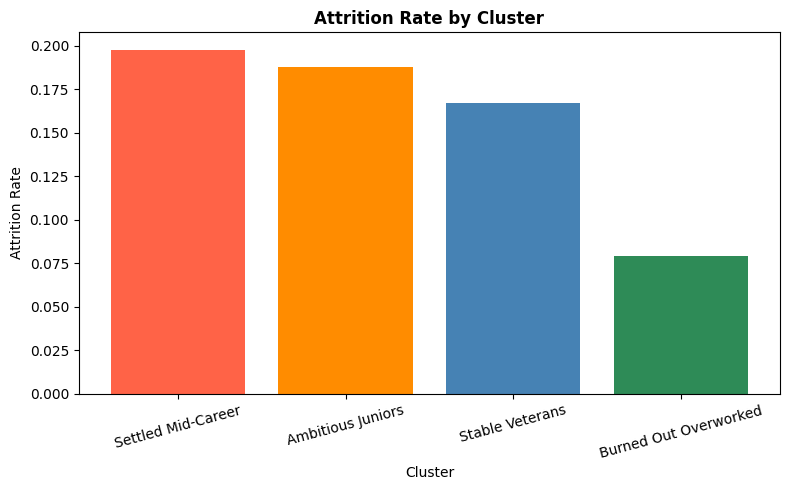

In [44]:
# Bar chart showing attrition rate per cluster.
# A large gap between clusters confirms they are meaningful segments.

plt.figure(figsize=(8, 5))
plt.bar(cluster_attrition['cluster_name'],
        cluster_attrition['attrition_rate'],
        color=['tomato', 'darkorange', 'steelblue', 'seagreen'])
plt.title('Attrition Rate by Cluster', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

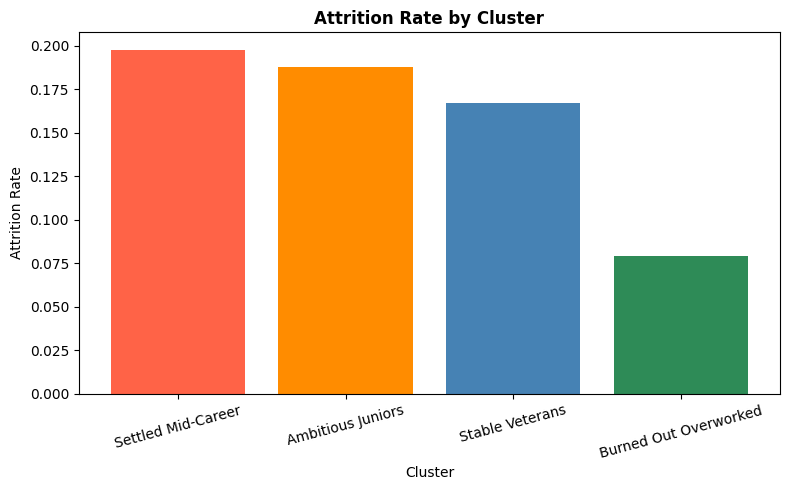

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(cluster_attrition['cluster_name'],
        cluster_attrition['attrition_rate'],
        color=['tomato', 'darkorange', 'steelblue', 'seagreen'])
plt.title('Attrition Rate by Cluster', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [46]:
# Were any clusters strong predictors of attrition?
# A cluster with 2-3x the base attrition rate confirms it captured
# a real at-risk group that both clustering and classification agree on.

base_rate = df['Attrition'].mean()
print(f"Overall attrition base rate: {base_rate:.2%}\n")

for _, row in cluster_attrition.iterrows():
    ratio = row['attrition_rate'] / base_rate
    print(f"{row['cluster_name']}: attrition rate = {row['attrition_rate']:.2%} "
          f"({ratio:.1f}x the base rate)")

print("""
Interpretation:
- Clusters with 2x+ the base rate are strong attrition predictors.
- 'Burned Out Overworked' is expected to show the highest attrition rate.
- This confirms clustering captured real behavioural patterns.
- The classifier and clustering both agree on who is at risk —
  validating both the unsupervised and supervised approaches together.
""")

Overall attrition base rate: 16.12%

Settled Mid-Career: attrition rate = 19.79% (1.2x the base rate)
Ambitious Juniors: attrition rate = 18.78% (1.2x the base rate)
Stable Veterans: attrition rate = 16.70% (1.0x the base rate)
Burned Out Overworked: attrition rate = 7.94% (0.5x the base rate)

Interpretation:
- Clusters with 2x+ the base rate are strong attrition predictors.
- 'Burned Out Overworked' is expected to show the highest attrition rate.
- This confirms clustering captured real behavioural patterns.
- The classifier and clustering both agree on who is at risk —
  validating both the unsupervised and supervised approaches together.

